In [2]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
from scipy.signal import find_peaks
from scipy.ndimage import gaussian_filter1d
import plotly.graph_objects as go
import sys
sys.path.append("../")
from scipy import stats
from tqdm import tqdm
from background_removal.main_background_removal import main_background_removal

In [140]:
def compute_grad_magnitude(img):
    grad_x = cv2.Sobel(img, ddepth=cv2.CV_64F, dx=1, dy=0)
    grad_y = cv2.Sobel(img, ddepth=cv2.CV_64F, dx=0, dy=1)
    grad_module = cv2.magnitude(grad_x, grad_y)
    return np.uint8(grad_module)

In [141]:
def get_discriminative_mask(img):
    hsv_image = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)

    h, s, v = cv2.split(hsv_image)
    edges_s = compute_grad_magnitude(s)
    edges_v = compute_grad_magnitude(v)

    mask_s = 0.5*edges_s + 0.5*edges_v
    mask_s = np.uint8(mask_s)
    mask_s[mask_s < 90] = 0
    mask_s[mask_s != 0] = 255

    mask = mask_s
    
    plt.imshow(mask,cmap='gray')
    plt.show()

    mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, cv2.getStructuringElement(cv2.MORPH_RECT, ksize=(10, 5)))
    mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, cv2.getStructuringElement(cv2.MORPH_RECT, ksize=(5, 10)))
    

    plt.imshow(mask,cmap='gray')
    plt.show()

    num_labels, labels, stats, centroids = cv2.connectedComponentsWithStats(mask)

    #For each label except background, get area and pick the two largest (possible two paintings)
    component_info = [(i, stats[i, 4]) for i in range(1, num_labels)]
    component_info.sort(key=lambda c: c[1], reverse=True)
    top_two_labels = [c[0] for c in component_info[:4]]

    new_mask = np.zeros_like(mask)

    for label in top_two_labels:

        
        # Create a mask of only this component
        ys, xs = np.where(labels == label)
        points = np.column_stack((xs, ys))
        
        # Get rotated rectangle from these points
        rect = cv2.minAreaRect(points)
        box = cv2.boxPoints(rect).astype(int)
        
        # Fill the rectangle in the mask
        cv2.fillPoly(new_mask, [box], 255)
        
    plt.imshow(new_mask,cmap='gray')
    plt.show()  
    
    
    return new_mask

def get_masks(img) -> list:
    
    AREA_THRESHOLD = (0.15*img.shape[0]) * (0.15*img.shape[1])
    discriminative_mask = get_discriminative_mask(img)

    # Check if there is more than one painting (big area)
    num_labels, _, stats, _ = cv2.connectedComponentsWithStats(discriminative_mask)
    small_areas = np.sum(stats[1:, 4] < AREA_THRESHOLD)
    # print(num_labels - small_areas - 1)
    if num_labels - small_areas - 1 > 1:
        
        #Sort stats from left painting to right painting (in case there are more than 2 in the future)
        stats_no_background = stats[1:]
        stats_no_background = stats_no_background[np.argsort(stats_no_background[:, 0])]
        
        #Compute their distances to get their image slice
        left_painting_x = stats_no_background[0, 0] + stats_no_background[0, 2]
        right_painting_x = stats_no_background[1, 0]
        distance = right_painting_x - left_painting_x
        middle_pos = left_painting_x + distance//2

        
        left_painting = img[:, 0:middle_pos]
        right_painting = img[:, middle_pos:]
        
        _, left_mask = main_background_removal(left_painting)
        _, right_mask = main_background_removal(right_painting)
        return [left_mask, right_mask]

    # print("Doing single mask")
    # plt.imshow(img)
    # plt.show()
    _, mask = main_background_removal(img)
    return [mask]

In [11]:
def has_impulse_noise(img, diff_threshold=60, ratio_threshold=0.01):
    median = cv2.medianBlur(img, 3)
    diff = cv2.absdiff(img, median)
    noisy_pixels = np.any(diff > diff_threshold, axis=2)
    noise_ratio = np.sum(noisy_pixels) / noisy_pixels.size
    return noise_ratio > ratio_threshold

In [4]:
from background_removal.main_background_removal import get_masks
from utils.noise_removal_methods import main_noise_removal

img1 = cv2.imread("data/qsd2_w3/00015.jpg", cv2.IMREAD_UNCHANGED)
print(img1)
img = main_noise_removal(img1)
masks = get_masks(img1)
print(len(masks))
mask = np.hstack(masks)
# _, mask = main_background_removal(img1)
plt.imshow(mask, cmap="gray")
plt.show()
print("Hola")

None


error: OpenCV(4.12.0) D:\a\opencv-python\opencv-python\opencv\modules\imgproc\src\color.cpp:199: error: (-215:Assertion failed) !_src.empty() in function 'cv::cvtColor'


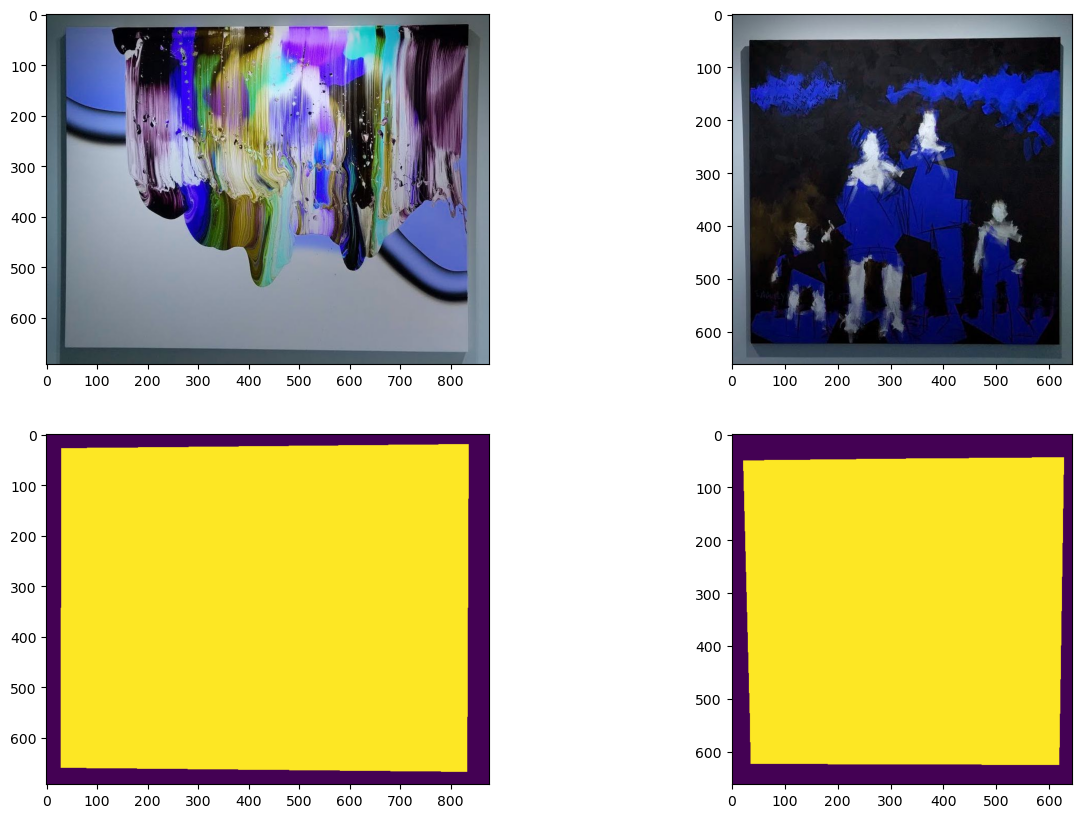

In [8]:
img1 = cv2.imread("../data/qsd2_w3/00021.jpg", cv2.IMREAD_UNCHANGED)
img2 = cv2.imread("../data/qsd2_w3/00009.jpg", cv2.IMREAD_UNCHANGED)
f, ax = plt.subplots(2, 2, figsize=(15,10))
ax[0][0].imshow(img1)
_, mask = main_background_removal(img1)
ax[1][0].imshow(mask)
ax[0][1].imshow(img2)
_, mask = main_background_removal(img2)
ax[1][1].imshow(mask)
plt.show()

In [ ]:
score = 0
precision = 0
recall = 0

for i in tqdm(range(30)):
    img = cv2.imread(f"../data/qsd2_w3/{i:05d}.jpg", cv2.IMREAD_UNCHANGED)
    if has_impulse_noise(img):
        img = cv2.medianBlur(img, 3)
    correct_img = cv2.imread(f"../data/qsd2_w3/{i:05d}.png", cv2.IMREAD_UNCHANGED)
    
    masks = get_masks(img)
    result = masks[0]
    if len(masks) > 1:
        left_mask = masks[0]
        right_mask = masks[1]
        result = np.column_stack([left_mask, right_mask])
    
    TP = np.sum(correct_img & result)
    FN = np.sum(correct_img & (255 - result))
    FP = np.sum((255 - correct_img) & result)
    TN = np.sum((255 - correct_img) & (255 - result))
    
    f, ax = plt.subplots(1, 4, figsize=(10, 8))
    f.suptitle(f"Image {i:05d}.png")
    plt.axis('off')
    ax[0].imshow(correct_img & result)
    ax[0].axis('off')
    ax[0].set_title("True Positive")
    
    ax[1].imshow(correct_img & (255 - result))
    ax[1].axis('off')
    ax[1].set_title("False Negative")
    
    ax[2].imshow((255 - correct_img) & result)
    ax[2].axis('off')
    ax[2].set_title("False Positive")
    
    ax[3].imshow((255 - correct_img) & (255 - result))
    ax[3].axis('off')
    ax[3].set_title("True Negative")
    
    plt.tight_layout(rect=[0, 0, 1, 1.5])
    
    plt.show()
    
    
    P = TP / (TP + FP)
    R = TP / (TP + FN)
    F_score = 2*(P*R/(P + R))
    
    score = score + F_score
    precision += P
    recall += R
    
    print(f"Precision: {P}\nRecall: {R}\nF_score: {F_score}")
    
print(f"Average F_score : {score/30}")
print(f"Average Precision : {precision/30}")
print(f"Average Recall : {recall/30}")

  0%|          | 0/30 [00:00<?, ?it/s]


ValueError: all the input arrays must have same number of dimensions, but the array at index 0 has 4 dimension(s) and the array at index 1 has 3 dimension(s)